In [1]:
!pip install gdown --quiet

import gdown
import os

FOLDER_ID = '1cihuwbmg4Qzb-S1Nq7vgkoeDxPv2E9_v'

if not os.path.exists('/content/demo_assets'):
    gdown.download_folder(
        id=FOLDER_ID,
        output='/content/demo_assets',
        quiet=False,
        use_cookies=False,
    )

WEIGHTS_DIR = '/content/demo_assets/weights'
IMAGES_DIR = '/content/demo_assets/demo_images'
CODE_DIR = '/content/demo_assets'

print('\nVerifying downloaded assets:')
for d, label in [(WEIGHTS_DIR, 'weights'), (IMAGES_DIR, 'demo_images'), (f'{CODE_DIR}/tpgsr', 'tpgsr code')]:
    if os.path.exists(d):
        n = len(os.listdir(d))
        print(f'  {label}: {n} files in {d}')
    else:
        print(f'  MISSING: {d}')

Retrieving folder contents


Retrieving folder 1xbe230r8Iti1_ydGADEFh_AupTeS93lC demo_images
Processing file 1Krnxyh7NTGz-PcT9oSm6BzDBjsa6v7lx demo_00_SAWMILL_clean.png
Processing file 1tW8seI-gyzE4Nfx4J9JrsKLWj95o-PQB demo_00_SAWMILL_degraded.png
Processing file 1JCb7j-AJik513B50w1dgjgmYaul47Rz8 demo_00_SAWMILL_mask.png
Processing file 1J4UI3tmVxwpchfKsGrzE2bdAAJQUbiVB demo_01_LOWEST_clean.png
Processing file 1pYf3aD9uBosLgjx6SC5yfxqsCM0EzJop demo_01_LOWEST_degraded.png
Processing file 1qZKG9NAcryKyiMTKWG6PXMY0_8Q2YWU1 demo_01_LOWEST_mask.png
Processing file 1PACj7MKWbq4HGP7ZYep6EvABnQ0PPMnS demo_02_Own_clean.png
Processing file 1Z_DAsA3RyEcv1mBmkG397_0ICMsdjBxf demo_02_Own_degraded.png
Processing file 1yzFi0lQCOicaaGohoqWMWYRUxV1ZYvpW demo_02_Own_mask.png
Processing file 1OU9GmfaaxQrWA8jmN0xKdDOQ9AUmwEQ4 demo_03_brewed_clean.png
Processing file 1DlEGhB4SKxUOVBNfvoSNCUlzUdFgAEQK demo_03_brewed_degraded.png
Processing file 16Sh0jjnprMqEkhV-XXGC6erIt4TL8iVa demo_03_brewed_mask.png
Processing file 11QLH8ioFWbcBCVT-u

Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1Krnxyh7NTGz-PcT9oSm6BzDBjsa6v7lx
To: /content/demo_assets/demo_images/demo_00_SAWMILL_clean.png
100%|██████████| 13.0k/13.0k [00:00<00:00, 19.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1tW8seI-gyzE4Nfx4J9JrsKLWj95o-PQB
To: /content/demo_assets/demo_images/demo_00_SAWMILL_degraded.png
100%|██████████| 8.90k/8.90k [00:00<00:00, 16.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=1JCb7j-AJik513B50w1dgjgmYaul47Rz8
To: /content/demo_assets/demo_images/demo_00_SAWMILL_mask.png
100%|██████████| 193/193 [00:00<00:00, 788kB/s]
Downloading...
From: https://drive.google.com/uc?id=1J4UI3tmVxwpchfKsGrzE2bdAAJQUbiVB
To: /content/demo_assets/demo_images/demo_01_LOWEST_clean.png
100%|██████████| 4.69k/4.69k [00:00<00:00, 10.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1pYf3aD9uBosLgjx6SC5yfxqsCM0EzJop
To: /


Verifying downloaded assets:
  weights: 8 files in /content/demo_assets/weights
  demo_images: 31 files in /content/demo_assets/demo_images
  tpgsr code: 7 files in /content/demo_assets/tpgsr



Download completed


In [2]:
import sys
if CODE_DIR not in sys.path:
    sys.path.insert(0, CODE_DIR)

import json
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__}')

Device: cuda
PyTorch: 2.10.0+cu128


CRNN ARCHITECTURE

In [3]:
import os
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim


# ---------------------------------------------------------------------------
# Model Architecture (matches Clovaai exactly)
# ---------------------------------------------------------------------------
class BidirectionalLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.rnn = nn.LSTM(input_size, hidden_size, bidirectional=True, batch_first=True)
        self.linear = nn.Linear(hidden_size * 2, output_size)

    def forward(self, x):
        recurrent, _ = self.rnn(x)
        return self.linear(recurrent)


class ClovaaiCRNN(nn.Module):
    """
    CRNN matching Clovaai's None-VGG-BiLSTM-CTC architecture.

    Key dimensions (for 32xW grayscale input):
      CNN: 1 -> 64 -> 128 -> 256 -> 256 -> 512(BN) -> 512(BN) -> 512(BN)
      Height: 32 -> 16 -> 8 -> 8 -> 4 -> 4 -> 2 -> 1
      Width:  W -> W/2 -> W/4 -> W/4 -> W/4 -> W/4 -> W/4 -> W/4
      So W=256 -> 64 time steps for the RNN.

    Args:
        num_classes:    alphabet size including CTC blank (index 0)
        input_channel:  1 for grayscale
        output_channel: 512 (CNN final output channels)
        hidden_size:    256 (BiLSTM hidden per direction)
    """

    def __init__(self, num_classes, input_channel=1, output_channel=512,
                 hidden_size=256):
        super().__init__()
        self.num_classes = num_classes
        self.hidden_size = hidden_size
        self.output_channel = output_channel

        # -- VGG Feature Extractor (matches Clovaai exactly) --
        # Channel progression: [64, 128, 256, 512]
        oc = [output_channel // 8, output_channel // 4,
              output_channel // 2, output_channel]  # [64, 128, 256, 512]

        self.FeatureExtraction = nn.Sequential(
            nn.Conv2d(input_channel, oc[0], 3, 1, 1), nn.ReLU(True),
            nn.MaxPool2d(2, 2),                                          # -> 64x16xW/2

            nn.Conv2d(oc[0], oc[1], 3, 1, 1), nn.ReLU(True),
            nn.MaxPool2d(2, 2),                                          # -> 128x8xW/4

            nn.Conv2d(oc[1], oc[2], 3, 1, 1), nn.ReLU(True),            # -> 256x8xW/4
            nn.Conv2d(oc[2], oc[2], 3, 1, 1), nn.ReLU(True),
            nn.MaxPool2d((2, 1), (2, 1)),                                # -> 256x4xW/4

            nn.Conv2d(oc[2], oc[3], 3, 1, 1, bias=False),
            nn.BatchNorm2d(oc[3]), nn.ReLU(True),                        # -> 512x4xW/4

            nn.Conv2d(oc[3], oc[3], 3, 1, 1, bias=False),
            nn.BatchNorm2d(oc[3]), nn.ReLU(True),
            nn.MaxPool2d((2, 1), (2, 1)),                                # -> 512x2xW/4

            nn.Conv2d(oc[3], oc[3], 2, 1, 0, bias=False),
            nn.BatchNorm2d(oc[3]), nn.ReLU(True),                        # -> 512x1xW/4
        )

        # Collapse height
        self.AdaptiveAvgPool = nn.AdaptiveAvgPool2d((None, 1))

        # -- BiLSTM Sequence Modeling --
        # Clovaai uses: BiLSTM(512->256->256) then BiLSTM(256->256->256)
        self.SequenceModeling = nn.Sequential(
            BidirectionalLSTM(output_channel, hidden_size, hidden_size),
            BidirectionalLSTM(hidden_size, hidden_size, hidden_size),
        )

        # -- CTC Prediction --
        # This layer gets replaced when loading pretrained weights
        self.Prediction = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        """
        Args:
            x: (B, 1, 32, W) grayscale input
        Returns:
            log_probs: (T, B, num_classes) for CTC
        """
        # CNN: (B, 1, 32, W) -> (B, 512, 1, W/4)
        visual = self.FeatureExtraction(x)

        # Permute and pool: (B, 512, 1, W/4) -> (B, W/4, 512)
        visual = visual.permute(0, 3, 1, 2)      # (B, W/4, 512, 1)
        visual = self.AdaptiveAvgPool(visual)     # (B, W/4, 512, 1)
        visual = visual.squeeze(3)                # (B, W/4, 512)

        # BiLSTM: (B, T, 512) -> (B, T, 256)
        contextual = self.SequenceModeling(visual)

        # Prediction: (B, T, 256) -> (B, T, num_classes)
        output = self.Prediction(contextual)

        # CTC format: (T, B, num_classes)
        output = output.permute(1, 0, 2)
        log_probs = F.log_softmax(output, dim=2)
        return log_probs

In [4]:
class LabelEncoder:
    """Maps characters <-> integer indices. Index 0 is reserved for CTC blank."""

    def __init__(self, charset: str):
        self.chars = ['[BLANK]'] + list(charset)
        self.char2idx = {c: i for i, c in enumerate(self.chars)}
        self.idx2char = {i: c for i, c in enumerate(self.chars)}
        self.num_classes = len(self.chars)

    def encode(self, text: str):
        """str -> LongTensor of indices. Unknown chars are rejected to catch normalization drift."""
        unknown_chars = sorted({ch for ch in text if ch not in self.char2idx})
        if unknown_chars:
            raise ValueError(
                f'Found characters outside the configured charset: {unknown_chars}. '
                'Normalize the dataset records before encoding.'
            )
        return torch.LongTensor([self.char2idx[ch] for ch in text])

    def decode(self, indices, remove_duplicates=True, remove_blank=True):
        """LongTensor/list -> str. Supports both plain label decode and CTC greedy decode."""
        invalid_indices = sorted({int(idx) for idx in indices if int(idx) not in self.idx2char})
        if invalid_indices:
            raise ValueError(f'Found indices outside the decoder vocabulary: {invalid_indices}')

        result = []
        prev = None
        for idx in indices:
            idx = int(idx)
            if remove_duplicates and idx == prev:
                prev = idx
                continue
            prev = idx
            if remove_blank and idx == 0:
                continue
            char = self.idx2char[idx]
            if char != '[BLANK]':
                result.append(char)
        return ''.join(result)
def greedy_decode(log_probs, label_encoder):
    """
    CTC greedy (best-path) decoding.

    Args:
        log_probs: (T, B, C) log-probabilities from the model
        label_encoder: LabelEncoder instance for index-to-char mapping

    Returns:
        list of decoded strings, one per batch element
    """
    # Argmax over classes at each time step
    _, preds = log_probs.max(2)  # (T, B)
    preds = preds.permute(1, 0)  # (B, T)

    decoded = []
    for i in range(preds.size(0)):
        raw = preds[i].cpu().tolist()
        text = label_encoder.decode(raw, remove_duplicates=True, remove_blank=True)
        decoded.append(text)
    return decoded

TRBA Architecture

In [5]:
# ---------------------------------------------------------------------------
# TRBA model architecture (matches Clovaai TPS-ResNet-BiLSTM-Attn)
# ---------------------------------------------------------------------------

import numpy as np


class TPS_SpatialTransformerNetwork(nn.Module):
    def __init__(self, F, I_size, I_r_size, I_channel_num=1):
        super().__init__()
        self.F = F
        self.I_size = I_size
        self.I_r_size = I_r_size
        self.I_channel_num = I_channel_num
        self.LocalizationNetwork = LocalizationNetwork(F, I_channel_num)
        self.GridGenerator = GridGenerator(F, I_r_size)

    def forward(self, batch_I):
        batch_C_prime = self.LocalizationNetwork(batch_I)
        build_P_prime = self.GridGenerator.build_P_prime(batch_C_prime)
        build_P_prime = build_P_prime.reshape(batch_I.size(0), self.I_r_size[0], self.I_r_size[1], 2)
        return F.grid_sample(batch_I, build_P_prime, padding_mode='border', align_corners=True)


class LocalizationNetwork(nn.Module):
    def __init__(self, F, I_channel_num):
        super().__init__()
        self.F = F
        self.I_channel_num = I_channel_num
        self.conv = nn.Sequential(
            nn.Conv2d(I_channel_num, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, 1, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(128, 256, 3, 1, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(256, 512, 3, 1, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),
            nn.AdaptiveAvgPool2d(1),
        )
        self.localization_fc1 = nn.Sequential(nn.Linear(512, 256), nn.ReLU(True))
        self.localization_fc2 = nn.Linear(256, F * 2)

        self.localization_fc2.weight.data.zero_()
        ctrl_pts_x = np.linspace(-1.0, 1.0, int(F / 2))
        ctrl_pts_y_top = np.linspace(0.0, -1.0, num=int(F / 2))
        ctrl_pts_y_bottom = np.linspace(1.0, 0.0, num=int(F / 2))
        ctrl_pts_top = np.stack([ctrl_pts_x, ctrl_pts_y_top], axis=1)
        ctrl_pts_bottom = np.stack([ctrl_pts_x, ctrl_pts_y_bottom], axis=1)
        initial_bias = np.concatenate([ctrl_pts_top, ctrl_pts_bottom], axis=0)
        self.localization_fc2.bias.data.copy_(torch.from_numpy(initial_bias).float().view(-1))

    def forward(self, batch_I):
        batch_size = batch_I.size(0)
        features = self.conv(batch_I).view(batch_size, -1)
        return self.localization_fc2(self.localization_fc1(features)).view(batch_size, self.F, 2)


class GridGenerator(nn.Module):
    def __init__(self, F, I_r_size):
        super().__init__()
        self.eps = 1e-6
        self.I_r_height, self.I_r_width = I_r_size
        self.F = F
        self.C = self._build_C(F)
        self.P = self._build_P(self.I_r_width, self.I_r_height)
        self.register_buffer('inv_delta_C', torch.tensor(self._build_inv_delta_C(F, self.C)).float())
        self.register_buffer('P_hat', torch.tensor(self._build_P_hat(F, self.C, self.P)).float())

    def _build_C(self, F):
        ctrl_pts_x = np.linspace(-1.0, 1.0, int(F / 2))
        ctrl_pts_y_top = -1 * np.ones(int(F / 2))
        ctrl_pts_y_bottom = np.ones(int(F / 2))
        ctrl_pts_top = np.stack([ctrl_pts_x, ctrl_pts_y_top], axis=1)
        ctrl_pts_bottom = np.stack([ctrl_pts_x, ctrl_pts_y_bottom], axis=1)
        return np.concatenate([ctrl_pts_top, ctrl_pts_bottom], axis=0)

    def _build_inv_delta_C(self, F, C):
        hat_C = np.zeros((F, F), dtype=float)
        for i in range(F):
            for j in range(i, F):
                r = np.linalg.norm(C[i] - C[j])
                hat_C[i, j] = r
                hat_C[j, i] = r
        np.fill_diagonal(hat_C, 1)
        hat_C = (hat_C ** 2) * np.log(hat_C)
        delta_C = np.concatenate(
            [
                np.concatenate([np.ones((F, 1)), C, hat_C], axis=1),
                np.concatenate([np.zeros((2, 3)), C.T], axis=1),
                np.concatenate([np.zeros((1, 3)), np.ones((1, F))], axis=1),
            ],
            axis=0,
        )
        return np.linalg.inv(delta_C)

    def _build_P(self, I_r_width, I_r_height):
        I_r_grid_x = (np.arange(-I_r_width, I_r_width, 2) + 1.0) / I_r_width
        I_r_grid_y = (np.arange(-I_r_height, I_r_height, 2) + 1.0) / I_r_height
        P = np.stack(np.meshgrid(I_r_grid_x, I_r_grid_y), axis=2)
        return P.reshape([-1, 2])

    def _build_P_hat(self, F, C, P):
        n = P.shape[0]
        P_tile = np.tile(np.expand_dims(P, axis=1), (1, F, 1))
        C_tile = np.expand_dims(C, axis=0)
        P_diff = P_tile - C_tile
        rbf_norm = np.linalg.norm(P_diff, ord=2, axis=2)
        rbf = np.multiply(np.square(rbf_norm), np.log(rbf_norm + self.eps))
        return np.concatenate([np.ones((n, 1)), P, rbf], axis=1)

    def build_P_prime(self, batch_C_prime):
        batch_size = batch_C_prime.size(0)
        batch_inv_delta_C = self.inv_delta_C.unsqueeze(0).repeat(batch_size, 1, 1)
        batch_P_hat = self.P_hat.unsqueeze(0).repeat(batch_size, 1, 1)
        zeros = torch.zeros(batch_size, 3, 2, device=batch_C_prime.device, dtype=batch_C_prime.dtype)
        batch_C_prime_with_zeros = torch.cat((batch_C_prime, zeros), dim=1)
        batch_T = torch.bmm(batch_inv_delta_C, batch_C_prime_with_zeros)
        return torch.bmm(batch_P_hat, batch_T)


class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super().__init__()
        self.conv1 = self._conv3x3(inplanes, planes, stride)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = self._conv3x3(planes, planes)
        self.bn2 = nn.BatchNorm2d(planes)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample
        self.stride = stride

    def _conv3x3(self, in_planes, out_planes, stride=1):
        return nn.Conv2d(in_planes, out_planes, kernel_size=3, stride=stride, padding=1, bias=False)

    def forward(self, x):
        residual = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            residual = self.downsample(x)

        out += residual
        out = self.relu(out)
        return out


class ResNet(nn.Module):
    def __init__(self, input_channel, output_channel, block, layers):
        super().__init__()
        self.output_channel_block = [int(output_channel / 4), int(output_channel / 2), output_channel, output_channel]
        self.inplanes = int(output_channel / 8)

        self.conv0_1 = nn.Conv2d(input_channel, int(output_channel / 16), kernel_size=3, stride=1, padding=1, bias=False)
        self.bn0_1 = nn.BatchNorm2d(int(output_channel / 16))
        self.conv0_2 = nn.Conv2d(int(output_channel / 16), self.inplanes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn0_2 = nn.BatchNorm2d(self.inplanes)
        self.relu = nn.ReLU(inplace=True)

        self.maxpool1 = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.layer1 = self._make_layer(block, self.output_channel_block[0], layers[0])
        self.conv1 = nn.Conv2d(self.output_channel_block[0], self.output_channel_block[0], kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(self.output_channel_block[0])

        self.maxpool2 = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.layer2 = self._make_layer(block, self.output_channel_block[1], layers[1], stride=1)
        self.conv2 = nn.Conv2d(self.output_channel_block[1], self.output_channel_block[1], kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(self.output_channel_block[1])

        self.maxpool3 = nn.MaxPool2d(kernel_size=2, stride=(2, 1), padding=(0, 1))
        self.layer3 = self._make_layer(block, self.output_channel_block[2], layers[2], stride=1)
        self.conv3 = nn.Conv2d(self.output_channel_block[2], self.output_channel_block[2], kernel_size=3, stride=1, padding=1, bias=False)
        self.bn3 = nn.BatchNorm2d(self.output_channel_block[2])

        self.layer4 = self._make_layer(block, self.output_channel_block[3], layers[3], stride=1)
        self.conv4_1 = nn.Conv2d(self.output_channel_block[3], self.output_channel_block[3], kernel_size=2, stride=(2, 1), padding=(0, 1), bias=False)
        self.bn4_1 = nn.BatchNorm2d(self.output_channel_block[3])
        self.conv4_2 = nn.Conv2d(self.output_channel_block[3], self.output_channel_block[3], kernel_size=2, stride=1, padding=0, bias=False)
        self.bn4_2 = nn.BatchNorm2d(self.output_channel_block[3])

    def _make_layer(self, block, planes, blocks, stride=1):
        downsample = None
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.inplanes, planes * block.expansion, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes * block.expansion),
            )

        layers = [block(self.inplanes, planes, stride, downsample)]
        self.inplanes = planes * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.inplanes, planes))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv0_1(x)
        x = self.bn0_1(x)
        x = self.relu(x)
        x = self.conv0_2(x)
        x = self.bn0_2(x)
        x = self.relu(x)

        x = self.maxpool1(x)
        x = self.layer1(x)
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.maxpool2(x)
        x = self.layer2(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)

        x = self.maxpool3(x)
        x = self.layer3(x)
        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu(x)

        x = self.layer4(x)
        x = self.conv4_1(x)
        x = self.bn4_1(x)
        x = self.relu(x)
        x = self.conv4_2(x)
        x = self.bn4_2(x)
        x = self.relu(x)
        return x


class ResNetFeatureExtractor(nn.Module):
    def __init__(self, input_channel, output_channel=512):
        super().__init__()
        self.ConvNet = ResNet(input_channel, output_channel, BasicBlock, [1, 2, 5, 3])

    def forward(self, x):
        return self.ConvNet(x)


class AttentionCell(nn.Module):
    def __init__(self, input_size, hidden_size, num_embeddings):
        super().__init__()
        self.i2h = nn.Linear(input_size, hidden_size, bias=False)
        self.h2h = nn.Linear(hidden_size, hidden_size)
        self.score = nn.Linear(hidden_size, 1, bias=False)
        self.rnn = nn.LSTMCell(input_size + num_embeddings, hidden_size)
        self.hidden_size = hidden_size

    def forward(self, prev_hidden, batch_H, char_onehots):
        batch_H_proj = self.i2h(batch_H)
        prev_hidden_proj = self.h2h(prev_hidden[0]).unsqueeze(1)
        e = self.score(torch.tanh(batch_H_proj + prev_hidden_proj))
        alpha = F.softmax(e, dim=1)
        context = torch.bmm(alpha.permute(0, 2, 1), batch_H).squeeze(1)
        concat_context = torch.cat([context, char_onehots], dim=1)
        cur_hidden = self.rnn(concat_context, prev_hidden)
        return cur_hidden, alpha


class Attention(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()
        self.attention_cell = AttentionCell(input_size, hidden_size, num_classes)
        self.hidden_size = hidden_size
        self.num_classes = num_classes
        self.generator = nn.Linear(hidden_size, num_classes)

    def _char_to_onehot(self, input_char, onehot_dim):
        input_char = input_char.unsqueeze(1)
        one_hot = torch.zeros(input_char.size(0), onehot_dim, device=input_char.device)
        return one_hot.scatter_(1, input_char, 1.0)

    def forward(self, batch_H, text, is_train=True, batch_max_length=25):
        batch_size = batch_H.size(0)
        num_steps = batch_max_length + 1
        output_hiddens = torch.zeros(batch_size, num_steps, self.hidden_size, device=batch_H.device)
        hidden = (
            torch.zeros(batch_size, self.hidden_size, device=batch_H.device),
            torch.zeros(batch_size, self.hidden_size, device=batch_H.device),
        )

        if is_train:
            for step in range(num_steps):
                char_onehots = self._char_to_onehot(text[:, step], onehot_dim=self.num_classes)
                hidden, _ = self.attention_cell(hidden, batch_H, char_onehots)
                output_hiddens[:, step, :] = hidden[0]
            return self.generator(output_hiddens)

        targets = torch.zeros(batch_size, dtype=torch.long, device=batch_H.device)
        probs = torch.zeros(batch_size, num_steps, self.num_classes, device=batch_H.device)
        for step in range(num_steps):
            char_onehots = self._char_to_onehot(targets, onehot_dim=self.num_classes)
            hidden, _ = self.attention_cell(hidden, batch_H, char_onehots)
            probs_step = self.generator(hidden[0])
            probs[:, step, :] = probs_step
            _, next_input = probs_step.max(dim=1)
            targets = next_input
        return probs


class ClovaaiTRBA(nn.Module):
    def __init__(self, num_class, cfg):
        super().__init__()
        self.cfg = cfg
        self.stages = {'Trans': 'TPS', 'Feat': 'ResNet', 'Seq': 'BiLSTM', 'Pred': 'Attn'}
        self.Transformation = TPS_SpatialTransformerNetwork(
            F=cfg.NUM_FIDUCIAL,
            I_size=(cfg.IMG_HEIGHT, cfg.IMG_WIDTH),
            I_r_size=(cfg.IMG_HEIGHT, cfg.IMG_WIDTH),
            I_channel_num=cfg.IMG_CHANNELS,
        )
        self.FeatureExtraction = ResNetFeatureExtractor(cfg.IMG_CHANNELS, cfg.CNN_OUT_CHANNELS)
        self.AdaptiveAvgPool = nn.AdaptiveAvgPool2d((None, 1))
        self.SequenceModeling = nn.Sequential(
            BidirectionalLSTM(cfg.CNN_OUT_CHANNELS, cfg.RNN_HIDDEN_SIZE, cfg.RNN_HIDDEN_SIZE),
            BidirectionalLSTM(cfg.RNN_HIDDEN_SIZE, cfg.RNN_HIDDEN_SIZE, cfg.RNN_HIDDEN_SIZE),
        )
        self.Prediction = Attention(cfg.RNN_HIDDEN_SIZE, cfg.RNN_HIDDEN_SIZE, num_class)

    def forward(self, images, text, is_train=True):
        images = self.Transformation(images)
        visual_feature = self.FeatureExtraction(images)
        visual_feature = self.AdaptiveAvgPool(visual_feature.permute(0, 3, 1, 2))
        visual_feature = visual_feature.squeeze(3)
        contextual_feature = self.SequenceModeling(visual_feature)
        return self.Prediction(
            contextual_feature.contiguous(),
            text,
            is_train=is_train,
            batch_max_length=self.cfg.BATCH_MAX_LENGTH,
        )

In [6]:
class AttnLabelConverter:
    """Character converter for attention-based decoding with [GO] and [s] tokens."""

    def __init__(self, character):
        self.character = ['[GO]', '[s]'] + list(character)
        self.dict = {char: idx for idx, char in enumerate(self.character)}
        self.go_idx = self.dict['[GO]']
        self.eos_idx = self.dict['[s]']

    def encode(self, texts, batch_max_length=25):
        lengths = [len(text) + 1 for text in texts]
        batch_text = torch.zeros(len(texts), batch_max_length + 2, dtype=torch.long)
        for row, text in enumerate(texts):
            tokens = list(text) + ['[s]']
            token_ids = [self.dict[token] for token in tokens]
            batch_text[row, 1:1 + len(token_ids)] = torch.tensor(token_ids, dtype=torch.long)
        return batch_text, torch.IntTensor(lengths)

    def decode(self, text_index, lengths=None):
        if isinstance(text_index, torch.Tensor):
            text_index = text_index.detach().cpu()
        texts = []
        for row in text_index:
            chars = []
            for token in row.tolist():
                char = self.character[int(token)]
                if char == '[GO]':
                    continue
                if char == '[s]':
                    break
                chars.append(char)
            texts.append(''.join(chars))
        return texts

Load Weights

In [7]:
# ---- Character sets ----
CRNN_CHARSET = '0123456789abcdefghijklmnopqrstuvwxyz'
TRBA_CHARSET = '0123456789abcdefghijklmnopqrstuvwxyz'

crnn_label_encoder = LabelEncoder(CRNN_CHARSET)
trba_converter = AttnLabelConverter(TRBA_CHARSET)
label_encoder = crnn_label_encoder

# ---- CRNN trio ----
def _load_crnn(ckpt_path):
    model = ClovaaiCRNN(
        num_classes=crnn_label_encoder.num_classes,
        input_channel=1,
        output_channel=512,
        hidden_size=256,
    ).to(DEVICE)
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    for p in model.parameters():
        p.requires_grad = False
    return model

print('Loading CRNN models...')
crnn_tpg      = _load_crnn(f'{WEIGHTS_DIR}/crnn_tpg_clean_v2_best.pth')
crnn_baseline = _load_crnn(f'{WEIGHTS_DIR}/crnn_totaltext_heavy_best.pth')
crnn_ft       = _load_crnn(f'{WEIGHTS_DIR}/crnn_tpgsr_finetuned_best.pth')
print('  CRNN TPG, baseline, fine-tuned loaded')

# ---- TRBA config (shared architecture dims) ----
class _TRBACfg:
    IMG_HEIGHT = 32
    IMG_WIDTH = 100
    IMG_CHANNELS = 1
    NUM_FIDUCIAL = 20
    BATCH_MAX_LENGTH = 25
    CNN_OUT_CHANNELS = 512
    RNN_HIDDEN_SIZE = 256
    DEVICE = DEVICE
trba_cfg = _TRBACfg()

def _load_trba(ckpt_path):
    model = ClovaaiTRBA(num_class=len(trba_converter.character), cfg=trba_cfg).to(DEVICE)
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    for p in model.parameters():
        p.requires_grad = False
    return model

print('Loading TRBA models...')
trba_tpg      = _load_trba(f'{WEIGHTS_DIR}/trba_tpg_clean_best.pth')
trba_baseline = _load_trba(f'{WEIGHTS_DIR}/trba_totaltext_heavy_best.pth')
trba_ft       = _load_trba(f'{WEIGHTS_DIR}/trba_tpgsr_finetuned_best.pth')
print('  TRBA TPG, baseline, fine-tuned loaded')
class _CRNNCfg:
    IMG_CHANNELS = 1
    CNN_OUT_CHANNELS = 512
    RNN_HIDDEN_SIZE = 256
    CHARSET = CRNN_CHARSET
cfg = _CRNNCfg()

Loading CRNN models...
  CRNN TPG, baseline, fine-tuned loaded
Loading TRBA models...
  TRBA TPG, baseline, fine-tuned loaded


LOAD TPGSR (TSRN + FROZEN TPG)

In [8]:
# Test TSRN instantiation in isolation
from tpgsr.tsrn import TSRN
test = TSRN(
    in_channels=4, out_channels=3, hidden_channels=64,
    num_blocks=5, scale=2, use_stn=True, prior_channels=32,
).to(DEVICE)
print('TSRN built OK')
print(f'Params: {sum(p.numel() for p in test.parameters())/1e6:.2f}M')
# Clear stale imports
import sys
for mod in list(sys.modules):
    if mod.startswith('tpgsr'):
        del sys.modules[mod]

from tpgsr.tsrn import TSRN
from tpgsr.tpgsr_model import TPGSR
from tpgsr.tpgsr_trba_model import TPGSRTRBA
from tpgsr.load_tpg import load_frozen_tpg
from tpgsr.load_trba_tpg import load_frozen_trba_tpg

# Inline configs
class TPGSRConfig:
    TPG_CHECKPOINT_PATH = f'{WEIGHTS_DIR}/crnn_tpg_clean_v2_best.pth'
    TPG_NUM_CLASSES = 37
    NUM_ITERATIONS = 2

class TPGSRTRBAConfig:
    TPG_CHECKPOINT_PATH = f'{WEIGHTS_DIR}/trba_tpg_clean_best.pth'
    TPG_NUM_CLASSES = 38
    NUM_ITERATIONS = 2
    BATCH_MAX_LENGTH = 25

tpgsr_cfg_crnn = TPGSRConfig()
tpgsr_cfg_trba = TPGSRTRBAConfig()

print('Imports OK')

TSRN built OK
Params: 0.78M
Imports OK


In [ ]:
import torch
_crnn_frozen_tpg = load_frozen_tpg(
    tpgsr_cfg_crnn.TPG_CHECKPOINT_PATH,
    tpgsr_cfg_crnn,
    DEVICE,
)
print('CRNN TPG loaded:', type(_crnn_frozen_tpg).__name__)
_tsrn_crnn = TSRN(
    in_channels=4, out_channels=3, hidden_channels=64,
    num_blocks=5, scale=2, use_stn=True, prior_channels=32,
).to(DEVICE)
print(f'TSRN built: {sum(p.numel() for p in _tsrn_crnn.parameters())/1e6:.2f}M params')
tpgsr_crnn = TPGSR(
    tsrn=_tsrn_crnn,
    tpg=_crnn_frozen_tpg,
    num_classes=tpgsr_cfg_crnn.TPG_NUM_CLASSES,
    num_iterations=tpgsr_cfg_crnn.NUM_ITERATIONS,
).to(DEVICE)

# Warm-up STN lazy FC before loading weights
with torch.no_grad():
    _ = tpgsr_crnn(torch.zeros(1, 4, 16, 64, device=DEVICE))

print('TPGSR CRNN wrapper built')
ckpt = torch.load(f'{WEIGHTS_DIR}/tsrn_heavy_best.pth', map_location=DEVICE, weights_only=False)
missing, unexpected = tpgsr_crnn.load_state_dict(ckpt['model_state_dict'], strict=False)
tpgsr_crnn.eval()
for p in tpgsr_crnn.parameters():
    p.requires_grad = False

print(f'Loaded epoch {ckpt["epoch"]}, val_tpg_acc={ckpt.get("val_tpg_acc", 0):.3f}')
if missing:
    print(f'Missing keys ({len(missing)}):', missing[:5], '...' if len(missing) > 5 else '')
if unexpected:
    print(f'Unexpected keys ({len(unexpected)}):', unexpected[:5], '...' if len(unexpected) > 5 else '')
# TRBA TPG

_trba_frozen_tpg = load_frozen_trba_tpg(
    tpgsr_cfg_trba.TPG_CHECKPOINT_PATH,  
    trba_cfg,                             
)
print('TRBA TPG loaded')

# TSRN for TRBA variant
_tsrn_trba = TSRN(
    in_channels=4, out_channels=3, hidden_channels=64,
    num_blocks=5, scale=2, use_stn=True, prior_channels=32,
).to(DEVICE)
print('TSRN (TRBA variant) built')

# TPGSRTRBA wrapper
tpgsr_trba = TPGSRTRBA(
    tsrn=_tsrn_trba,
    trba=_trba_frozen_tpg,
    num_classes=tpgsr_cfg_trba.TPG_NUM_CLASSES,
    num_iterations=tpgsr_cfg_trba.NUM_ITERATIONS,
    prior_feat_channels=32,
    lr_spatial_size=(16, 64),
    trba_image_size=(32, 100),
    batch_max_length=tpgsr_cfg_trba.BATCH_MAX_LENGTH,
).to(DEVICE)

with torch.no_grad():
    _ = tpgsr_trba(torch.zeros(1, 4, 16, 64, device=DEVICE))
print('TPGSR TRBA wrapper built')

# Load weights
ckpt = torch.load(f'{WEIGHTS_DIR}/tsrn_heavy_trba_best.pth', map_location=DEVICE, weights_only=False)
missing, unexpected = tpgsr_trba.load_state_dict(ckpt['model_state_dict'], strict=False)
tpgsr_trba.eval()
for p in tpgsr_trba.parameters():
    p.requires_grad = False
print(f'Loaded epoch {ckpt["epoch"]}')

TPG loaded from /content/demo_assets/weights/crnn_tpg_clean_v2_best.pth
  checkpoint epoch: 12, val_acc: 60.4%, val_cer: 26.9%
CRNN TPG loaded: ClovaaiCRNN
TSRN built: 0.78M params
TPGSR CRNN wrapper built
Loaded epoch 26, val_tpg_acc=0.189
TRBA-TPG loaded from /content/demo_assets/weights/trba_tpg_clean_best.pth
  checkpoint epoch: 8, val_acc: 66.3%, val_cer: 23.5%
TRBA TPG loaded
TSRN (TRBA variant) built
TPGSR TRBA wrapper built
Loaded epoch 21


INFERENCE HELPERS DEFINED

In [10]:
LR_H, LR_W = 16, 64
HR_H, HR_W = 32, 128

def _to_tensor_tanh(np_img_rgb_uint8):
    t = torch.from_numpy(np_img_rgb_uint8).permute(2, 0, 1).float() / 127.5 - 1.0
    return t

def _to_mask_tensor(np_mask_uint8, target_size):
    mask = cv2.resize(np_mask_uint8, (target_size[1], target_size[0]), interpolation=cv2.INTER_NEAREST)
    t = torch.from_numpy(mask).float().unsqueeze(0) / 255.0
    return t

def prepare_tsrn_input(degraded_path, mask_path):
    """Return (1, 4, 16, 64) tensor ready for TSRN."""
    bgr = cv2.imread(degraded_path, cv2.IMREAD_COLOR)
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    lr_rgb = cv2.resize(rgb, (LR_W, LR_H), interpolation=cv2.INTER_CUBIC)
    lr_t = _to_tensor_tanh(lr_rgb)  # (3, 16, 64)

    if mask_path and os.path.exists(mask_path):
        m = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    else:
        m = np.full(rgb.shape[:2], 255, dtype=np.uint8)
    mask_t = _to_mask_tensor(m, (LR_H, LR_W))  # (1, 16, 64)

    return torch.cat([lr_t, mask_t], dim=0).unsqueeze(0).to(DEVICE)

def tensor_to_rgb_uint8(t):
    """(3, H, W) tanh-range tensor -> (H, W, 3) uint8 RGB numpy."""
    arr = ((t.detach().cpu() + 1) * 127.5).clamp(0, 255).byte().permute(1, 2, 0).numpy()
    return arr

@torch.no_grad()
def run_tpgsr(tpgsr_model, tsrn_input_4ch):
    out = tpgsr_model(tsrn_input_4ch)
    return out['final_sr']  # (1, 3, 32, 128)

@torch.no_grad()
def predict_crnn(model, rgb_uint8_or_path):
    """Accept either a (H,W,3) uint8 numpy or a file path. Returns predicted string."""
    if isinstance(rgb_uint8_or_path, str):
        bgr = cv2.imread(rgb_uint8_or_path, cv2.IMREAD_COLOR)
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    else:
        rgb = rgb_uint8_or_path
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    # Keep-ratio pad to 32x128
    h, w = gray.shape
    if h != 32:
        new_w = max(1, int(round(w * 32 / max(h, 1))))
        gray = cv2.resize(gray, (new_w, 32), interpolation=cv2.INTER_CUBIC)
        h, w = gray.shape
    if w > 128:
        gray = cv2.resize(gray, (128, 32), interpolation=cv2.INTER_CUBIC)
    elif w < 128:
        gray = cv2.copyMakeBorder(gray, 0, 0, 0, 128 - w, cv2.BORDER_REPLICATE)
    t = torch.from_numpy(gray).float().unsqueeze(0).unsqueeze(0) / 127.5 - 1.0
    t = t.to(DEVICE)
    log_probs = model(t)  # (T, 1, C)
    return greedy_decode(log_probs, crnn_label_encoder)[0]

@torch.no_grad()
def predict_trba(model, rgb_uint8_or_path):
    """Run TRBA autoregressive inference. Returns predicted string."""
    if isinstance(rgb_uint8_or_path, str):
        bgr = cv2.imread(rgb_uint8_or_path, cv2.IMREAD_COLOR)
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    else:
        rgb = rgb_uint8_or_path
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    # Keep-ratio pad to 32x100 for TRBA
    h, w = gray.shape
    if h != 32:
        new_w = max(1, int(round(w * 32 / max(h, 1))))
        gray = cv2.resize(gray, (new_w, 32), interpolation=cv2.INTER_CUBIC)
        h, w = gray.shape
    if w > 100:
        gray = cv2.resize(gray, (100, 32), interpolation=cv2.INTER_CUBIC)
    elif w < 100:
        gray = cv2.copyMakeBorder(gray, 0, 0, 0, 100 - w, cv2.BORDER_REPLICATE)
    t = torch.from_numpy(gray).float().unsqueeze(0).unsqueeze(0) / 127.5 - 1.0
    t = t.to(DEVICE)
    text_placeholder = torch.zeros(1, trba_cfg.BATCH_MAX_LENGTH + 1, dtype=torch.long, device=DEVICE)
    logits = model(t, text_placeholder, is_train=False)  # (1, 26, 38)
    _, preds_idx = logits.max(2)
    return trba_converter.decode(preds_idx)[0]

print('Inference helpers defined.')

Inference helpers defined.


Processing demo images

In [11]:
# Load demo labels
with open(f'{IMAGES_DIR}/demo_labels.json') as f:
    demo_labels = json.load(f)

demo_stems = sorted(demo_labels.keys())
print(f'Found {len(demo_stems)} demo images')

results = []

for stem in demo_stems:
    gt_text = demo_labels[stem]['text'] if isinstance(demo_labels[stem], dict) else demo_labels[stem]

    clean_path    = f'{IMAGES_DIR}/{stem}_clean.png'
    degraded_path = f'{IMAGES_DIR}/{stem}_degraded.png'
    mask_path     = f'{IMAGES_DIR}/{stem}_mask.png'

    if not (os.path.exists(clean_path) and os.path.exists(degraded_path)):
        print(f'Skipping {stem}: missing files')
        continue

    # Build TSRN input and run both TPGSR variants
    tsrn_input = prepare_tsrn_input(degraded_path, mask_path if os.path.exists(mask_path) else None)
    sr_crnn = run_tpgsr(tpgsr_crnn, tsrn_input)  # (1, 3, 32, 128)
    sr_trba = run_tpgsr(tpgsr_trba, tsrn_input)

    sr_crnn_rgb = tensor_to_rgb_uint8(sr_crnn[0])
    sr_trba_rgb = tensor_to_rgb_uint8(sr_trba[0])

    # Predictions
    pred_baseline_crnn = predict_crnn(crnn_baseline, degraded_path)
    pred_tpgsr_crnn    = predict_crnn(crnn_ft,      sr_crnn_rgb)
    pred_baseline_trba = predict_trba(trba_baseline, degraded_path)
    pred_tpgsr_trba    = predict_trba(trba_ft,      sr_trba_rgb)

    results.append({
        'stem': stem,
        'gt': gt_text,
        'clean_path': clean_path,
        'degraded_path': degraded_path,
        'mask_path': mask_path if os.path.exists(mask_path) else None,
        'sr_crnn_rgb': sr_crnn_rgb,
        'sr_trba_rgb': sr_trba_rgb,
        'pred_baseline_crnn': pred_baseline_crnn,
        'pred_tpgsr_crnn': pred_tpgsr_crnn,
        'pred_baseline_trba': pred_baseline_trba,
        'pred_tpgsr_trba': pred_tpgsr_trba,
    })

    print(f'  {stem}: GT="{gt_text}" | '
          f'baseline_CRNN="{pred_baseline_crnn}" | tpgsr_CRNN="{pred_tpgsr_crnn}" | '
          f'baseline_TRBA="{pred_baseline_trba}" | tpgsr_TRBA="{pred_tpgsr_trba}"')

print(f'\nDone. {len(results)} images processed.')

Found 10 demo images
  demo_00_SAWMILL: GT="SAWMILL" | baseline_CRNN="sawme" | tpgsr_CRNN="lawma" | baseline_TRBA="sammill" | tpgsr_TRBA="sawmill"
  demo_01_LOWEST: GT="LOWEST" | baseline_CRNN="lowest" | tpgsr_CRNN="lowest" | baseline_TRBA="lowest" | tpgsr_TRBA="lowest"
  demo_02_Own: GT="Own" | baseline_CRNN="owa" | tpgsr_CRNN="ownt" | baseline_TRBA="own" | tpgsr_TRBA="own"
  demo_03_brewed: GT="brewed" | baseline_CRNN="brewed" | tpgsr_CRNN="brewed" | baseline_TRBA="brewed" | tpgsr_TRBA="brewed"
  demo_04_SOX: GT="SOX" | baseline_CRNN="sox" | tpgsr_CRNN="ox" | baseline_TRBA="sox" | tpgsr_TRBA="sox"
  demo_05_Kay: GT="Kay" | baseline_CRNN="kay" | tpgsr_CRNN="kay" | baseline_TRBA="kay" | tpgsr_TRBA="kay"
  demo_06_DOORS: GT="DOORS" | baseline_CRNN="doors" | tpgsr_CRNN="doors" | baseline_TRBA="doors" | tpgsr_TRBA="doors"
  demo_07_Assorted: GT="Assorted" | baseline_CRNN="mong" | tpgsr_CRNN="sre" | baseline_TRBA="mance" | tpgsr_TRBA="states"
  demo_08_ALAN: GT="ALAN" | baseline_CRNN="alan

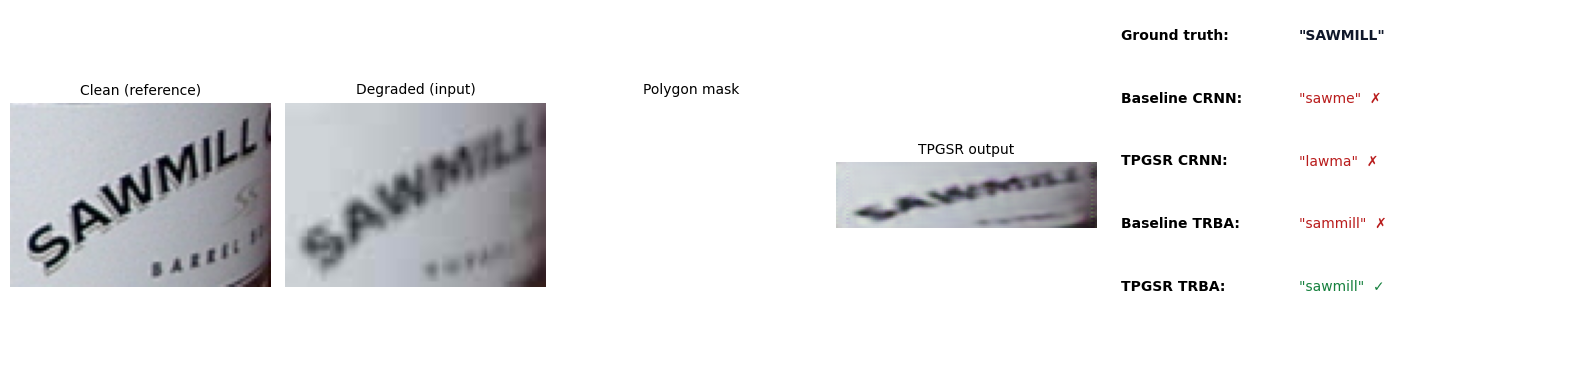

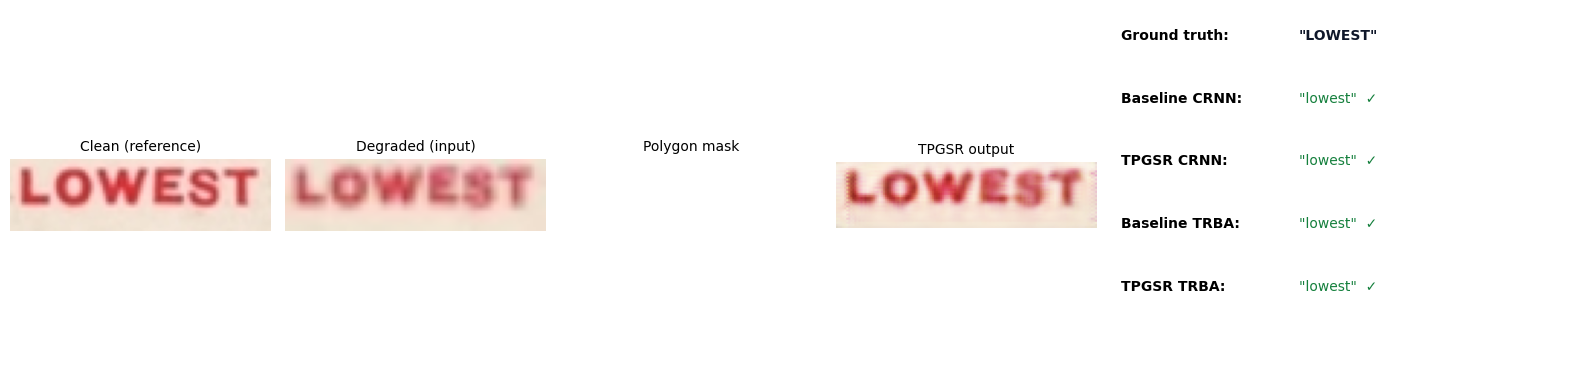

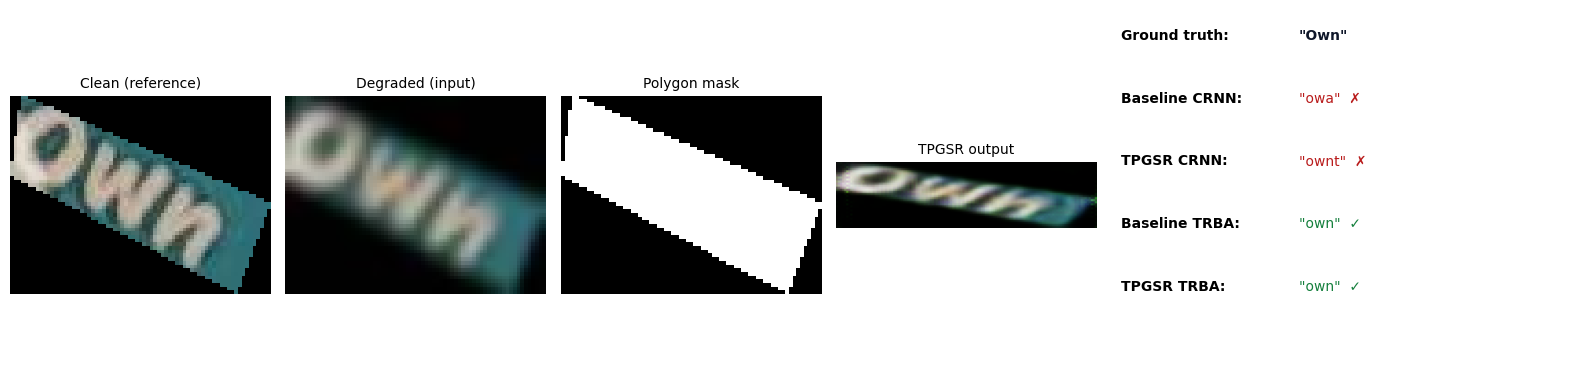

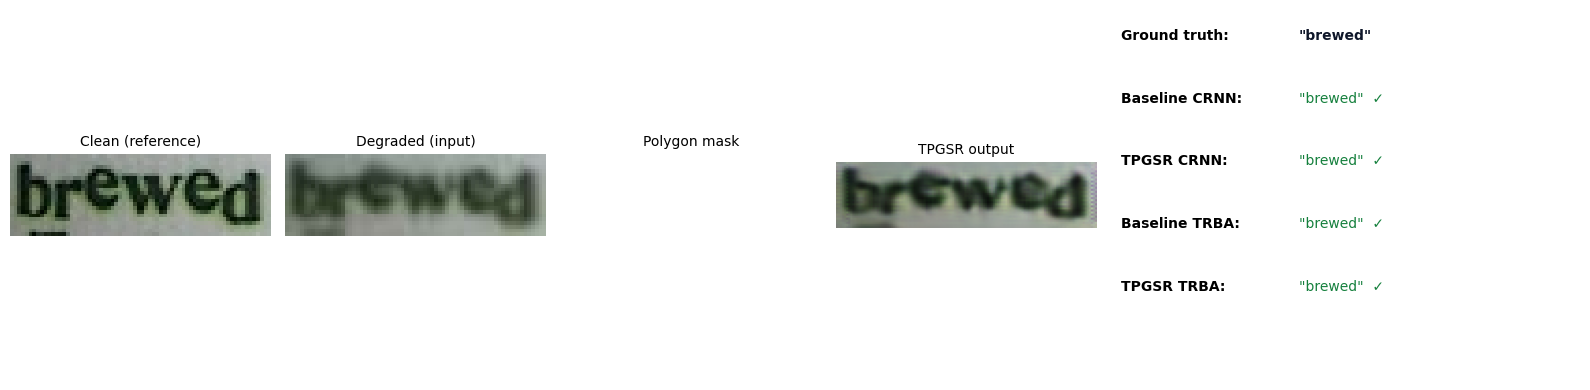

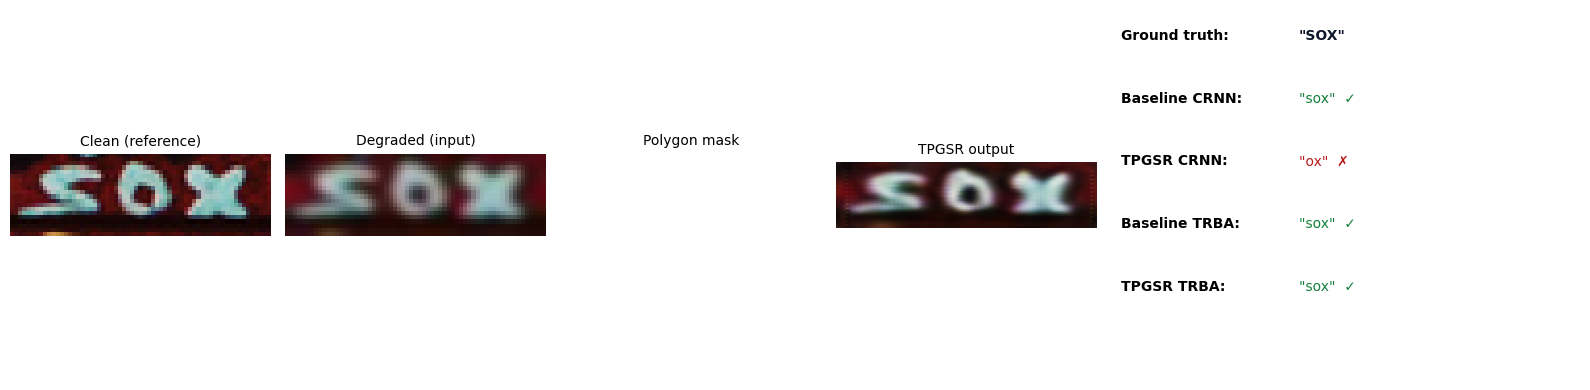

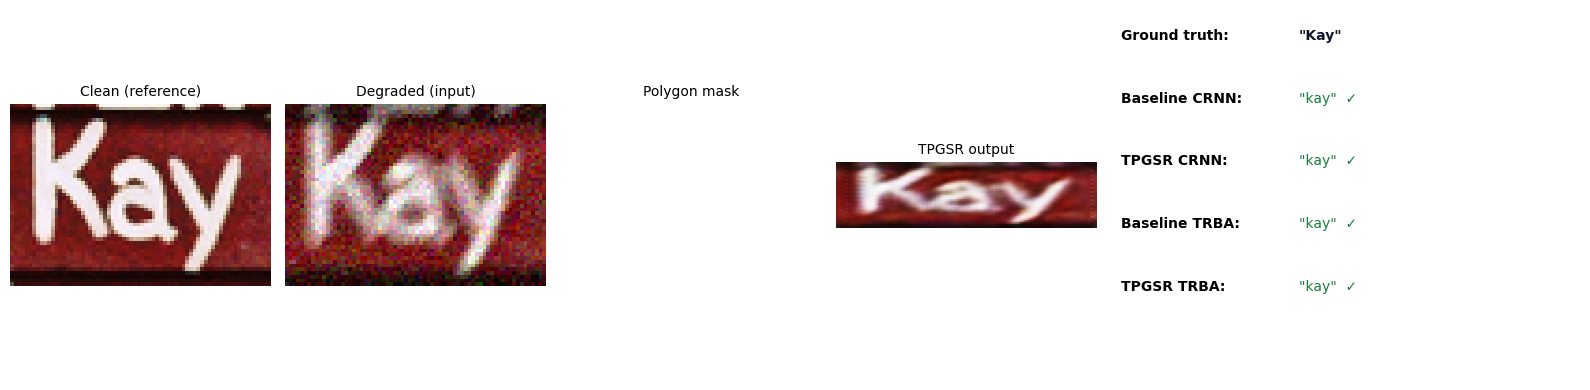

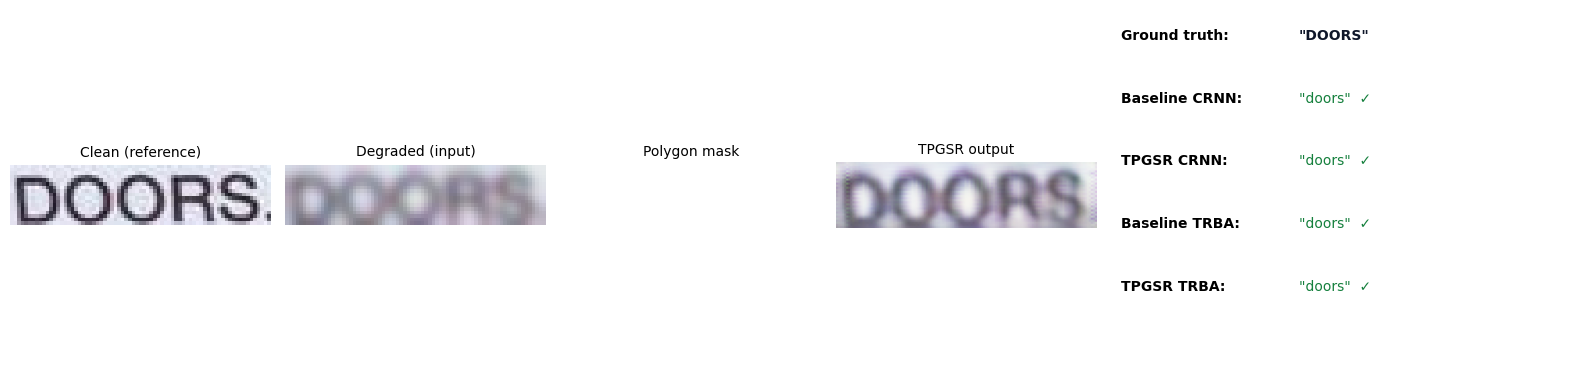

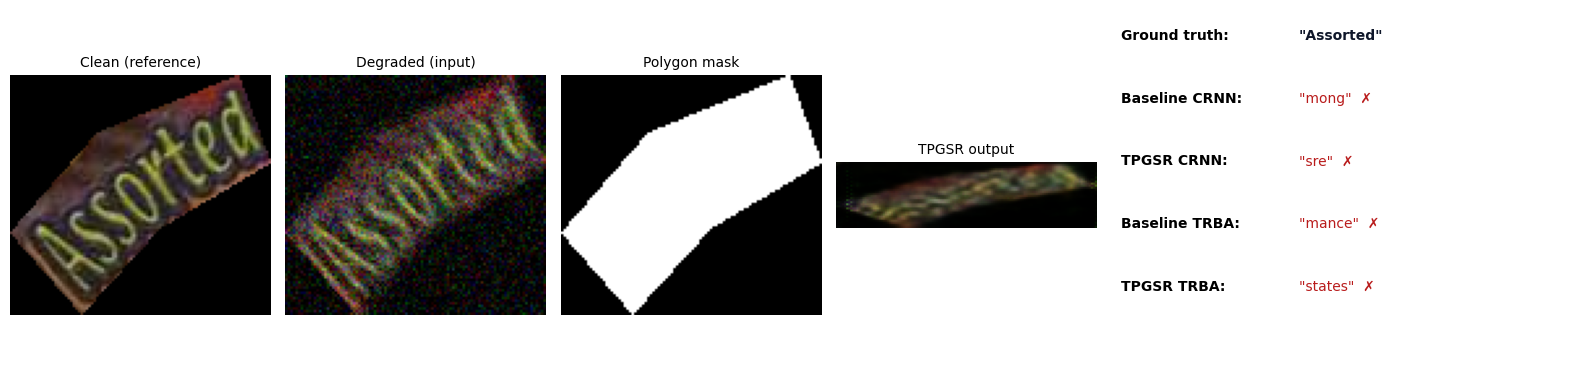

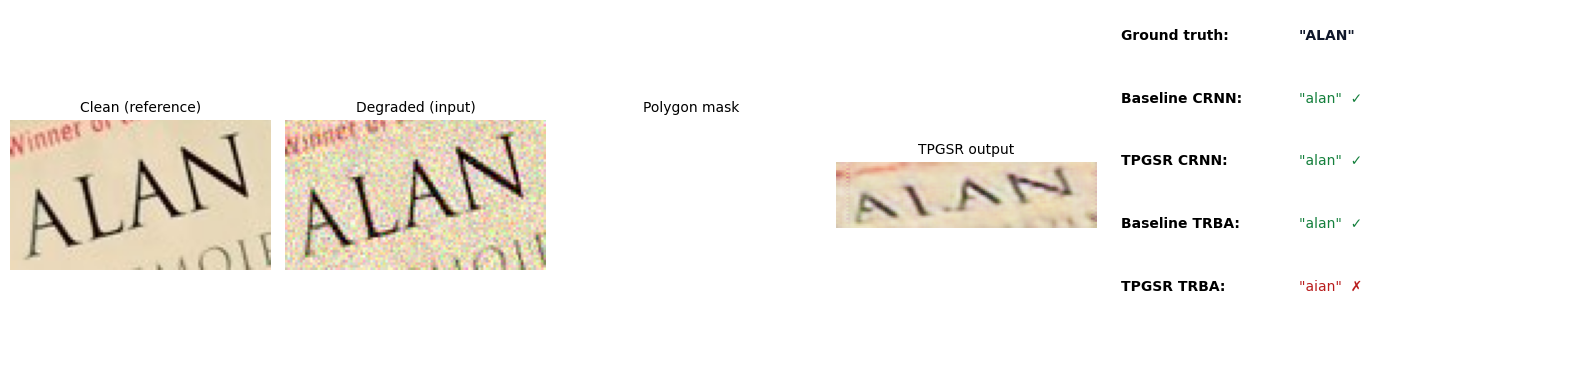

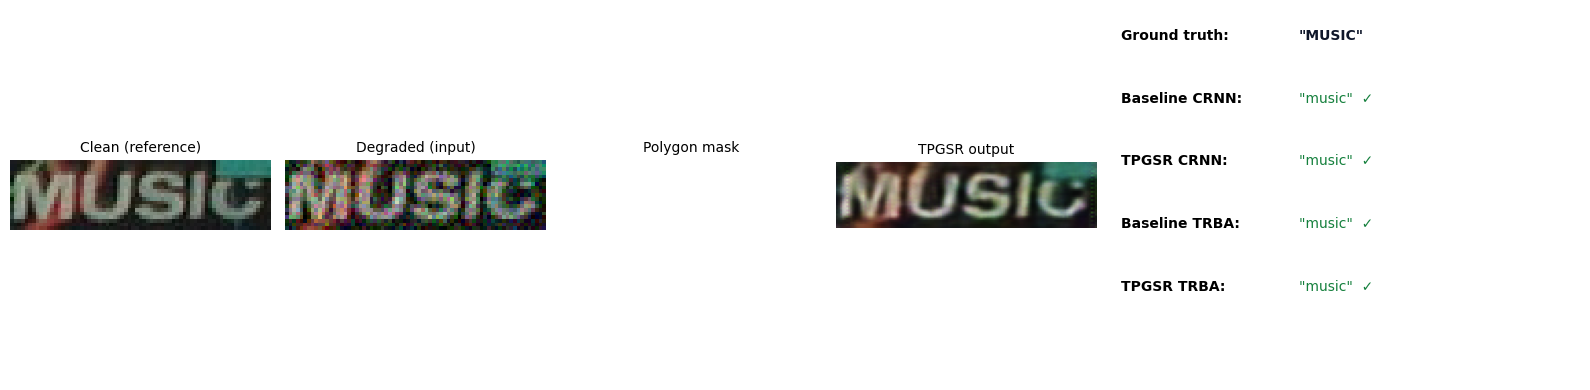

In [ ]:
def _load_rgb(path):
    bgr = cv2.imread(path, cv2.IMREAD_COLOR)
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

def _check(pred, gt):
    return pred.lower() == gt.lower()

def show_result(r, figsize=(16, 4)):
    gt = r['gt']

    sr_rgb = r['sr_crnn_rgb']

    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(1, 5, width_ratios=[1, 1, 1, 1, 1.8])

    # Panel 1: clean
    ax = fig.add_subplot(gs[0, 0])
    ax.imshow(_load_rgb(r['clean_path']))
    ax.set_title('Clean (reference)', fontsize=10)
    ax.axis('off')

    # Panel 2: degraded
    ax = fig.add_subplot(gs[0, 1])
    ax.imshow(_load_rgb(r['degraded_path']))
    ax.set_title('Degraded (input)', fontsize=10)
    ax.axis('off')

    # Panel 3: mask
    ax = fig.add_subplot(gs[0, 2])
    if r['mask_path']:
        mask = cv2.imread(r['mask_path'], cv2.IMREAD_GRAYSCALE)
        ax.imshow(mask, cmap='gray', vmin=0, vmax=255)
    else:
        ax.text(0.5, 0.5, 'no mask', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('Polygon mask', fontsize=10)
    ax.axis('off')

    # Panel 4: SR output
    ax = fig.add_subplot(gs[0, 3])
    ax.imshow(sr_rgb)
    ax.set_title('TPGSR output', fontsize=10)
    ax.axis('off')

    # Panel 5: predictions
    ax = fig.add_subplot(gs[0, 4])
    ax.axis('off')

    rows = [
        ('Ground truth',       gt,                      None),
        ('Baseline CRNN',      r['pred_baseline_crnn'], _check(r['pred_baseline_crnn'], gt)),
        ('TPGSR CRNN',         r['pred_tpgsr_crnn'],    _check(r['pred_tpgsr_crnn'], gt)),
        ('Baseline TRBA',      r['pred_baseline_trba'], _check(r['pred_baseline_trba'], gt)),
        ('TPGSR TRBA',         r['pred_tpgsr_trba'],    _check(r['pred_tpgsr_trba'], gt)),
    ]

    y = 0.92
    for label, text, correct in rows:
        if correct is None:
            color = '#0f172a'
            marker = ''
            weight = 'bold'
        elif correct:
            color = '#15803d'
            marker = '  ✓'
            weight = 'normal'
        else:
            color = '#b91c1c'
            marker = '  ✗'
            weight = 'normal'
        ax.text(0.02, y, f'{label}:', fontsize=10, fontweight='bold', transform=ax.transAxes)
        ax.text(0.40, y, f'"{text}"{marker}', fontsize=10, color=color, fontweight=weight, transform=ax.transAxes)
        y -= 0.17

    plt.tight_layout()
    plt.show()

for r in results:
    show_result(r)